# Numerical experiments

References: `src/market_making_experiments.jl`, `market_making_tn_report.ipynb` (exact + TT-SVD), `market_making_dmrg.ipynb` (variational DMRG):

1. **Baselines** — Gaussian harmonic (Thm. 7.4), product diagonal (Thm. 7.1), **factor-grid reduction**
2. **Finite horizon** — exact Krylov *and* MPS split-step TEBD imaginary-time evolution
3. **Doob chain** — simulate inventory jumps from \(\phi_0\) and verify \(\pi(q)\propto\phi_0(q)^2\) (Thm. 4.8)
4. **Site orderings** — seriation vs. correlation-chain permutations
5. **Phase diagram** — minimal bond dimension \(\chi_\epsilon\) for residual tolerance

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))
using MPSFast
using LinearAlgebra
using SparseArrays
using Random
using Printf

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/Inter Science/MPSFast.jl`


## 1. Experiment with $N=8$

In [2]:
rng = MersenneTwister(42)
model, Δ, B, cores = report_benchmark_model()
H = build_hamiltonian_sparse(model)
vals, vecs = exact_ground_states(H; nev=2, rng=rng)
E0, E1 = vals
ϕ0 = vecs[1]
ΔH = E1 - E0
edges = central_grid_edges(model.Qs)
@printf "N=%d  |Q|=%d  E0=%.8f  ΔH=%.8f  edges=%d\n" model.N hilbert_dim(model) E0 ΔH length(edges)

N=8  |Q|=390625  E0=-10.36159622  ΔH=1.15752138  edges=104976


## 2. Baselines: product, Gaussian, and factor-grid

In [3]:
cmp = baseline_quote_comparison(model, Δ, B, ϕ0, edges)
@printf "Product (diag Σ)  RMSE = %.4e\n" cmp.product.rmse
@printf "Gaussian harmonic RMSE = %.4e\n" cmp.gaussian.rmse
@printf "Factor-grid       RMSE = %.4e\n" cmp.factor_grid.rmse

Product (diag Σ)  RMSE = 1.6492e-01
Gaussian harmonic RMSE = 9.9455e-02
Factor-grid       RMSE = 9.1475e-01


## 3. Finite-horizon: exact Krylov vs MPS TEBD (Thm. 4.6)

In [4]:
τs = [0.0, 1.0, 5.0]
exact_fh = finite_horizon_quote_convergence(model, H, ϕ0, τs)
mps_fh = finite_horizon_mps_convergence(model, cores, ϕ0, τs; dt=0.5, maxdim=12)
for (τ, re, rm) in zip(τs, exact_fh.rmse, mps_fh.rmse)
    @printf "τ=%4.0f  exact=%.4e  MPS=%.4e\n" τ re rm
end

τ=   0  exact=8.1273e-01  MPS=8.1273e-01
τ=   1  exact=7.9672e-02  MPS=9.1673e-05
τ=   5  exact=9.4963e-06  MPS=2.6245e-05


## 4. Doob ground-state inventory chain (Thm. 4.8)

In [5]:
dedges = doob_rates_from_phi(ϕ0, model)
D = hilbert_dim(model)
π = ϕ0 .^ 2; π ./= sum(π)
traj = simulate_doob_chain(dedges, D, 500_000; rng=MersenneTwister(7), init=argmax(π))
occ_err = doob_occupancy_error(traj, ϕ0)
mix = doob_mixing_steps(traj, ϕ0; threshold=0.05)
@printf "occupancy L2 error = %.4e\n" occ_err
@printf "mixing jumps (empirical TV<0.05) = %d\n" mix

occupancy L2 error = 2.7531e-03
mixing jumps (empirical TV<0.05) = 557


## 5. Site-ordering sweep (DMRG at $\chi=16$)

In [6]:
for (name, perm) in (("natural", collect(1:8)),
                     ("seriation", seriation_order(model.Σ)),
                     ("corr-chain", correlation_chain_order(model.Σ)))
    mp, Δp, Bp, coresp, _ = permute_factor_model(model, Δ, B, perm)
    E, mps, _ = dmrg_ground_state(coresp; maxdim=16, n_sweeps=8, rng=MersenneTwister(99))
    rel = dmrg_relative_residual(mps, coresp, E)
    @printf "%-12s  E=%.8f  rel_resid=%.3e\n" name E rel
end

natural       E=-10.36159622  rel_resid=3.924e-06
seriation     E=-10.36159622  rel_resid=3.926e-06
corr-chain    E=-10.36159622  rel_resid=3.926e-06


## 6. Phase diagram — full grid ($N\in\{20,50,100\}$, $K\in\{1,2,3,5\}$, $d\in\{5,11\}$)

In [7]:
for (i, spec) in enumerate(default_phase_diagram_specs())
    N, K, Q, fs = spec
    sweeps = N >= 50 ? 4 : 6
    pt = phase_diagram_point(N, K; Q=Q, factor_strength=fs, eps_res=1e-2,
        chi_candidates=[4, 8, 16, 24, 32, 48, 64], n_sweeps=sweeps,
        rng=MersenneTwister(1000 + i))
    @printf "N=%3d K=%d d=%2d  χ_ε=%2d  rel=%.2e  E0=%.5f\n" N K (2Q+1) pt.chi pt.rel_residual pt.E0
end

N= 20 K=1 d= 5  χ_ε= 4  rel=6.28e-05  E0=-25.95939
N= 20 K=1 d=11  χ_ε= 4  rel=2.66e-05  E0=-27.07989
N= 20 K=2 d= 5  χ_ε= 4  rel=8.63e-04  E0=-27.21365
N= 20 K=2 d=11  χ_ε= 4  rel=5.93e-04  E0=-27.19753
N= 20 K=3 d= 5  χ_ε= 4  rel=1.12e-03  E0=-27.60227
N= 20 K=3 d=11  χ_ε= 4  rel=6.99e-04  E0=-26.75459
N= 20 K=5 d= 5  χ_ε= 4  rel=2.24e-03  E0=-26.37748
N= 20 K=5 d=11  χ_ε= 4  rel=1.17e-03  E0=-27.33598
N= 50 K=1 d= 5  χ_ε= 4  rel=3.52e-05  E0=-68.17390
N= 50 K=1 d=11  χ_ε= 4  rel=1.23e-05  E0=-69.55158
N= 50 K=2 d= 5  χ_ε= 4  rel=5.49e-04  E0=-68.22830
N= 50 K=2 d=11  χ_ε= 4  rel=2.81e-04  E0=-69.63156
N= 50 K=3 d= 5  χ_ε= 4  rel=5.49e-04  E0=-67.72410
N= 50 K=3 d=11  χ_ε= 4  rel=2.83e-04  E0=-68.92179
N= 50 K=5 d= 5  χ_ε= 4  rel=1.48e-03  E0=-68.91574
N= 50 K=5 d=11  χ_ε= 4  rel=9.34e-04  E0=-69.62326
N=100 K=1 d= 5  χ_ε= 4  rel=1.80e-05  E0=-136.83159
N=100 K=1 d=11  χ_ε= 4  rel=6.58e-06  E0=-137.11565
N=100 K=2 d= 5  χ_ε= 4  rel=2.93e-04  E0=-137.25249
N=100 K=2 d=11  χ_ε= 4  rel=

## 7. Reproducibility

The same numbers are produced by `scripts/run_sec10_experiments.jl`. Regression tests live in `test/runtests.jl` under `experiments:`.

## 8. Scaling audit and controlled stress sweep

The original phase grid is useful as a solver smoke test, but its conclusion that every case passes at $\chi=4$ is not a scaling result. It uses a loose energy-scaled residual tolerance, one realization per grid point, global factor normalization that weakens the typical per-asset coupling as $N$ grows, and no quote-error criterion.

The revised experiment in `scripts/run_scaling_stress_experiments.jl` controls the factor strength through
$$
\rho=\frac{\lVert BB^\top\rVert_2}{\min_i\Delta_i},
$$
reports the absolute Ritz residual, and measures quote stability on sampled central-region edges relative to a $\chi=32$ solution. It varies $N$, factor strength, factor rank, and local inventory dimension while holding the other parameters fixed where possible.

Main preliminary findings:

- At fixed $K=3$, $d=5$, and $\rho=1$, no systematic deterioration is visible between $N=20$ and $N=100$ up to $\chi=32$.
- Strong coupling is substantially harder: for $N=50$, $K=3$, $d=5$, and $\rho=10$, even $\chi=32$ has Ritz residual $1.51\times10^{-1}$.
- Increasing $K$ from 1 to 5 strongly increases residual and quote error at fixed $N$ and $\rho$.
- Increasing $d$ from 5 to 11 has a moderate accuracy effect but raises the $\chi=32$ runtime from about 28 seconds to 219 seconds.

The full numerical data and figures are stored in `notes/coutinho/figures/scaling_stress.csv`, `scaling_with_assets.pdf`, and `scaling_stress_chi8.pdf`. Quote differences use $\chi=32$ as an internal reference and are therefore stability diagnostics, not certified errors; this limitation is especially important when the reference residual remains large.

## 9. Strong-coupling multi-seed follow-up

The difficult case $N=50$, $K=3$, $d=5$, and $\rho=10$ was rerun with five independent initializations at $\chi=32$, three at $\chi=64$, and one at $\chi=96$. Every run used eight DMRG sweeps, and quote stability was evaluated on 500 sampled central-region edges.

The median Ritz residual decreases from $1.50\times10^{-1}$ at $\chi=32$ to $3.01\times10^{-2}$ at $\chi=64$; the $\chi=96$ residual is $1.13\times10^{-2}$. Residuals are tightly clustered across seeds, indicating that limited bond dimension, rather than distinct high-energy local minima, is the main numerical restriction.

Quotes are less stable than energies. Relative to the lowest-energy $\chi=96$ run, quote RMSE ranges from $0.299$ to $0.360$ at $\chi=32$ and from $0.119$ to $0.129$ at $\chi=64$, even though energies at each bond dimension are nearly identical. This supports the report's warning that energy convergence can hide policy error.

The $\chi=96$ state remains unconverged, so these quote values are internal stability diagnostics rather than exact errors. The experiment is reproducible with `scripts/run_strong_coupling_multiseed.jl`; data and figures are stored in `notes/coutinho/figures/strong_coupling_multiseed.csv` and `strong_coupling_multiseed.pdf`.

# Configurable long-run workbench

The cells below provide a resumable workbench for larger scaling experiments. Completed DMRG runs are checkpointed individually, so the same configuration can be executed again after an interruption without losing finished points.

Use separate `instance_seeds` to generate different models and `dmrg_seeds` to test optimization robustness on each fixed model. Quote errors use the lowest-energy run at the largest available bond dimension as an internal reference; they are stability diagnostics unless that reference is independently certified.

In [16]:
using JLD2
using Plots
using Statistics
using Dates

# Keep this false while editing or previewing the grid.
RUN_EXPERIMENTS = false

WB_CONFIG = (
    # Safe starter grid: d = 2Q + 1. Expand after measuring runtime.
    Ns = [20, 50],
    Ks = [3],
    Qs = [2],
    rhos = [1.0, 10.0],
    chis = [16, 32],

    # Separate model uncertainty from DMRG initialization uncertainty.
    instance_seeds = [1],
    dmrg_seeds = [1, 2],

    # Solver and quote-metric settings.
    n_sweeps = 8,
    cutoff = 1e-13,
    quote_edges = 500,
    central_radius = 1,

    # Financial/model parameters.
    k = 1.0,
    gamma = 1.1,
    eta_center = 1.0,
    eta_halfwidth = 0.1,

    # Change the tag when starting a conceptually different experiment.
    tag = "scaling_v1",
    overwrite = false,
)

WB_REPO_ROOT = normpath(joinpath(@__DIR__, "..", ".."))
WB_RESULTS_ROOT = get(
    ENV,
    "MPSFAST_RESULTS_DIR",
    joinpath(WB_REPO_ROOT, "results", "market_making"),
)
WB_OUTPUT_ROOT = joinpath(WB_RESULTS_ROOT, "workbench", WB_CONFIG.tag)
WB_CHECKPOINT_DIR = joinpath(WB_OUTPUT_ROOT, "checkpoints")
mkpath(WB_CHECKPOINT_DIR)

println("Output directory: ", WB_OUTPUT_ROOT)

Output directory: /Users/bi006881/dev/Notes on Time Series Generation for Options Pricing/notes/coutinho/figures/workbench/scaling_v1


In [17]:
function wb_model(N, K, Q, rho, instance_seed, cfg)
    rng = MersenneTwister(instance_seed)
    Δ = 0.6 .+ 0.3 .* rand(rng, N)
    η = cfg.eta_center .+ cfg.eta_halfwidth .* (2 .* rand(rng, N) .- 1)
    Braw = randn(rng, N, K)

    # Controlled factor strength: ||BB'||₂ / min(Δ) = rho.
    B = sqrt(rho * minimum(Δ)) .* Braw ./ opnorm(Braw)
    Σ = Diagonal(Δ) + B * B'
    model = MarketMakingModel(N, fill(Q, N), Matrix(Σ), zeros(N), cfg.k, cfg.gamma, η)
    cores = build_mpo_cores(model, Δ, B)
    actual_rho = opnorm(B)^2 / minimum(Δ)
    return model, Δ, B, cores, actual_rho
end

wb_float_tag(x) = replace(replace(string(x), "." => "p"), "-" => "m")

function wb_run_id(N, K, Q, rho, instance_seed, chi, dmrg_seed)
    return "N$(N)_K$(K)_Q$(Q)_rho$(wb_float_tag(rho))_instance$(instance_seed)_chi$(chi)_dmrg$(dmrg_seed)"
end

function wb_checkpoint_path(N, K, Q, rho, instance_seed, chi, dmrg_seed)
    return joinpath(WB_CHECKPOINT_DIR, wb_run_id(N, K, Q, rho, instance_seed, chi, dmrg_seed) * ".jld2")
end

function wb_sampled_edges(N, Q, count, radius; seed)
    rng = MersenneTwister(seed)
    r = min(radius, max(Q - 1, 0))
    edges = Tuple{Vector{Int},Vector{Int}}[]
    for _ in 1:count
        q = r == 0 ? zeros(Int, N) : rand(rng, -r:r, N)
        qn = copy(q)
        i = rand(rng, 1:N)
        qn[i] += rand(rng, Bool) ? 1 : -1
        push!(edges, (q, qn))
    end
    return edges
end

# Stable log-amplitude evaluation: normalize the partial contraction at every site.
function wb_logabs_amplitude(mps, x)
    v = Vector{Float64}(mps[1][1, x[1], :])
    scale = norm(v)
    scale > 0 || return -Inf
    logabs = log(scale)
    v ./= scale
    for j in 2:length(mps)
        v = vec(v' * mps[j][:, x[j], :])
        scale = norm(v)
        scale > 0 || return -Inf
        logabs += log(scale)
        v ./= scale
    end
    return logabs
end

function wb_log_ratio(mps, q, qn, Qs)
    return wb_logabs_amplitude(mps, q .+ Qs .+ 1) -
           wb_logabs_amplitude(mps, qn .+ Qs .+ 1)
end

function wb_quote_rmse(mps, reference, edges, Qs, k)
    errors = Float64[]
    for (q, qn) in edges
        value = (wb_log_ratio(mps, q, qn, Qs) - wb_log_ratio(reference, q, qn, Qs)) / k
        isfinite(value) && push!(errors, value)
    end
    isempty(errors) && return Inf
    return sqrt(mean(abs2, errors))
end

wb_quote_rmse (generic function with 1 method)

In [18]:
function wb_total_jobs(cfg)
    return length(cfg.Ns) * length(cfg.Ks) * length(cfg.Qs) * length(cfg.rhos) *
           length(cfg.instance_seeds) * length(cfg.chis) * length(cfg.dmrg_seeds)
end

function wb_completed_jobs(cfg)
    completed = 0
    for N in cfg.Ns, K in cfg.Ks, Q in cfg.Qs, rho in cfg.rhos,
        instance_seed in cfg.instance_seeds, chi in cfg.chis, dmrg_seed in cfg.dmrg_seeds
        path = wb_checkpoint_path(N, K, Q, rho, instance_seed, chi, dmrg_seed)
        completed += isfile(path)
    end
    return completed
end

function wb_run_grid(cfg)
    total = wb_total_jobs(cfg)
    completed_before = wb_completed_jobs(cfg)
    @printf "Grid contains %d runs; %d checkpoints already exist.\n" total completed_before
    job = 0

    for N in cfg.Ns, K in cfg.Ks, Q in cfg.Qs, rho in cfg.rhos,
        instance_seed in cfg.instance_seeds

        model, Δ, B, cores, actual_rho = wb_model(N, K, Q, rho, instance_seed, cfg)

        for chi in cfg.chis, dmrg_seed in cfg.dmrg_seeds
            job += 1
            path = wb_checkpoint_path(N, K, Q, rho, instance_seed, chi, dmrg_seed)
            if isfile(path) && !cfg.overwrite
                @printf "[%d/%d] skip %s\n" job total basename(path)
                continue
            end

            solver_seed = 1_000_000 * instance_seed + 1_000 * chi + dmrg_seed
            @printf(
                "[%d/%d] run N=%d K=%d d=%d rho=%.3g chi=%d instance=%d dmrg=%d\n",
                job, total, N, K, 2Q + 1, rho, chi, instance_seed, dmrg_seed,
            )
            flush(stdout)

            try
                elapsed = @elapsed begin
                    E, mps, history = dmrg_ground_state(
                        cores;
                        maxdim=chi,
                        n_sweeps=cfg.n_sweeps,
                        cutoff=cfg.cutoff,
                        rng=MersenneTwister(solver_seed),
                    )
                end
                residual = dmrg_residual(mps, cores, E)
                scaled_residual = residual / max(abs(E), 1.0)
                final_local_energy_change = length(history) > 1 ? abs(history[end] - history[end - 1]) : NaN

                jldsave(
                    path;
                    N, K, Q, d=2Q + 1, rho, actual_rho, instance_seed,
                    chi, dmrg_seed, solver_seed, E, residual, scaled_residual,
                    elapsed, final_local_energy_change, mps, history,
                    n_sweeps=cfg.n_sweeps, cutoff=cfg.cutoff,
                    timestamp=string(now()),
                )
                @printf "         E=%.10f residual=%.3e time=%.1fs saved\n" E residual elapsed
                flush(stdout)
            catch err
                @error "Run failed; completed checkpoints are safe" N K Q rho instance_seed chi dmrg_seed exception=(err, catch_backtrace())
            end
        end
    end
end

total_jobs = wb_total_jobs(WB_CONFIG)
completed_jobs = wb_completed_jobs(WB_CONFIG)
@printf(
    "Configured runs: %d; completed: %d; pending: %d\n",
    total_jobs, completed_jobs, total_jobs - completed_jobs,
)

Configured runs: 16; completed: 0; pending: 16


In [19]:
if RUN_EXPERIMENTS
    wb_run_grid(WB_CONFIG)
else
    println("Dry run only. Review WB_CONFIG, then set RUN_EXPERIMENTS = true.")
end

Grid contains 16 runs; 0 checkpoints already exist.
[1/16] run N=20 K=3 d=5 rho=1 chi=16 instance=1 dmrg=1
         E=-27.9751750375 residual=2.229e-03 time=4.0s saved
[2/16] run N=20 K=3 d=5 rho=1 chi=16 instance=1 dmrg=2
         E=-27.9751750376 residual=2.229e-03 time=3.1s saved
[3/16] run N=20 K=3 d=5 rho=1 chi=32 instance=1 dmrg=1
         E=-27.9751756320 residual=2.041e-04 time=12.6s saved
[4/16] run N=20 K=3 d=5 rho=1 chi=32 instance=1 dmrg=2
         E=-27.9751756320 residual=2.040e-04 time=12.1s saved
[5/16] run N=20 K=3 d=5 rho=10 chi=16 instance=1 dmrg=1
         E=-25.5280255906 residual=3.411e-01 time=7.2s saved
[6/16] run N=20 K=3 d=5 rho=10 chi=16 instance=1 dmrg=2
         E=-25.5284110566 residual=3.395e-01 time=7.5s saved
[7/16] run N=20 K=3 d=5 rho=10 chi=32 instance=1 dmrg=1
         E=-25.5363131969 residual=9.795e-02 time=26.9s saved
[8/16] run N=20 K=3 d=5 rho=10 chi=32 instance=1 dmrg=2
         E=-25.5363192223 residual=9.743e-02 time=26.5s saved
[9/16] run N

In [20]:
COMPUTE_QUOTE_ERRORS = true

function wb_checkpoint_records(cfg)
    records = NamedTuple[]
    for N in cfg.Ns, K in cfg.Ks, Q in cfg.Qs, rho in cfg.rhos,
        instance_seed in cfg.instance_seeds, chi in cfg.chis, dmrg_seed in cfg.dmrg_seeds
        path = wb_checkpoint_path(N, K, Q, rho, instance_seed, chi, dmrg_seed)
        isfile(path) || continue
        data = load(path)
        push!(records, (;
            N=Int(data["N"]), K=Int(data["K"]), Q=Int(data["Q"]), d=Int(data["d"]),
            rho=Float64(data["rho"]), instance_seed=Int(data["instance_seed"]),
            chi=Int(data["chi"]), dmrg_seed=Int(data["dmrg_seed"]),
            E=Float64(data["E"]), residual=Float64(data["residual"]),
            scaled_residual=Float64(data["scaled_residual"]),
            elapsed=Float64(data["elapsed"]), path,
        ))
    end
    return records
end

wb_group_key(r) = (r.N, r.K, r.Q, r.rho, r.instance_seed)

function wb_build_summary(cfg; compute_quote_errors=true)
    base_records = wb_checkpoint_records(cfg)
    isempty(base_records) && return NamedTuple[]
    results = NamedTuple[]

    for key in unique(wb_group_key.(base_records))
        group = filter(r -> wb_group_key(r) == key, base_records)
        reference_chi = maximum(getproperty.(group, :chi))
        reference_candidates = filter(r -> r.chi == reference_chi, group)
        reference = reference_candidates[argmin(getproperty.(reference_candidates, :E))]
        reference_data = compute_quote_errors ? load(reference.path) : nothing
        reference_mps = compute_quote_errors ? reference_data["mps"] : nothing
        N, K, Q, rho, instance_seed = key
        edge_seed = 10_000_000 + 10_000 * N + 100 * K + 10 * Q + instance_seed
        edges = compute_quote_errors ?
            wb_sampled_edges(N, Q, cfg.quote_edges, cfg.central_radius; seed=edge_seed) :
            nothing

        for record in group
            policy_rmse = if compute_quote_errors
                candidate_mps = load(record.path, "mps")
                wb_quote_rmse(candidate_mps, reference_mps, edges, fill(Q, N), cfg.k)
            else
                NaN
            end
            push!(results, (;
                record...,
                energy_above_reference=record.E - reference.E,
                quote_rmse=policy_rmse,
                reference_chi,
                reference_seed=reference.dmrg_seed,
                reference_residual=reference.residual,
            ))
        end
    end

    csv_path = joinpath(WB_OUTPUT_ROOT, "summary.csv")
    open(csv_path, "w") do io
        println(io, "N,K,Q,d,rho,instance_seed,chi,dmrg_seed,E,energy_above_reference,residual,scaled_residual,quote_rmse,reference_chi,reference_seed,reference_residual,elapsed_seconds")
        for r in results
            println(io, join((r.N,r.K,r.Q,r.d,r.rho,r.instance_seed,r.chi,r.dmrg_seed,r.E,
                r.energy_above_reference,r.residual,r.scaled_residual,r.quote_rmse,
                r.reference_chi,r.reference_seed,r.reference_residual,r.elapsed), ","))
        end
    end
    println("Summary written to ", csv_path)
    return results
end

WB_RESULTS = wb_build_summary(WB_CONFIG; compute_quote_errors=COMPUTE_QUOTE_ERRORS)
println("Loaded ", length(WB_RESULTS), " completed runs.")

Summary written to /Users/bi006881/dev/Notes on Time Series Generation for Options Pricing/notes/coutinho/figures/workbench/scaling_v1/summary.csv
Loaded 16 completed runs.


## Workbench figures

The plotting cells use `WB_RESULTS`, so they can be rerun without repeating DMRG. Change the selectors at the top of each cell. Curves aggregate all selected model and DMRG seeds using the median; faint points show individual runs.

A zero quote RMSE identifies the run chosen as its group's internal reference. Always inspect `reference_residual` in `summary.csv`: quote comparisons are not reliable as exact errors when that residual is still large.

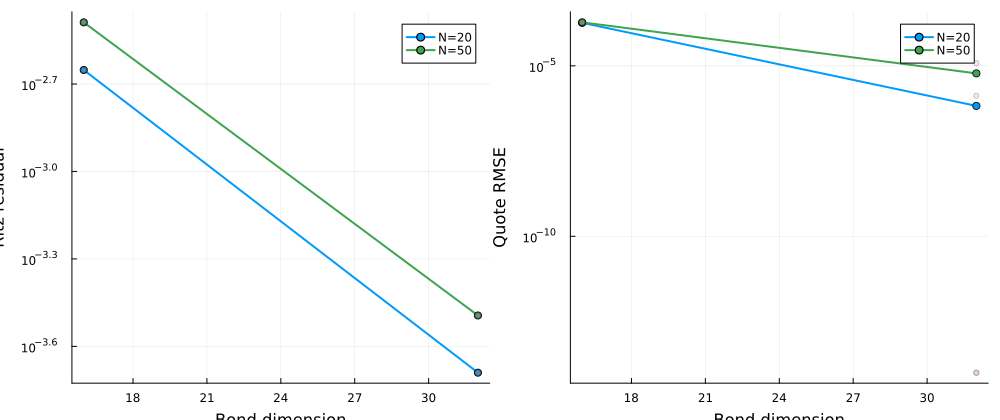

In [21]:
# Figure A: convergence with chi for several values of N.
PLOT_SCALING = (K=3, Q=2, rho=1.0)

function wb_median_by_chi(records, metric)
    chis = sort(unique(getproperty.(records, :chi)))
    values = [median([getproperty(r, metric) for r in records if r.chi == chi]) for chi in chis]
    return chis, values
end

function wb_scaling_figure(results, selector)
    selected = filter(r -> r.K == selector.K && r.Q == selector.Q && r.rho == selector.rho, results)
    isempty(selected) && error("No completed runs match PLOT_SCALING")
    Ns = sort(unique(getproperty.(selected, :N)))
    p_residual = plot(yscale=:log10, xlabel="Bond dimension", ylabel="Ritz residual", grid=true)
    p_quote = plot(yscale=:log10, xlabel="Bond dimension", ylabel="Quote RMSE", grid=true)

    for N in Ns
        group = filter(r -> r.N == N, selected)
        chis, residuals = wb_median_by_chi(group, :residual)
        _, quotes = wb_median_by_chi(group, :quote_rmse)
        plot!(p_residual, chis, residuals; marker=:circle, linewidth=2, label="N=$N")
        plot!(p_quote, chis, max.(quotes, 1e-14); marker=:circle, linewidth=2, label="N=$N")
        scatter!(p_residual, getproperty.(group, :chi), getproperty.(group, :residual);
            alpha=0.2, markersize=3, label=false)
        scatter!(p_quote, getproperty.(group, :chi), max.(getproperty.(group, :quote_rmse), 1e-14);
            alpha=0.2, markersize=3, label=false)
    end

    fig = plot(p_residual, p_quote; layout=(1,2), size=(1000,420))
    savefig(fig, joinpath(WB_OUTPUT_ROOT, "scaling_with_N.pdf"))
    savefig(fig, joinpath(WB_OUTPUT_ROOT, "scaling_with_N.png"))
    return fig
end

isempty(WB_RESULTS) ? println("Run or load experiments first.") : wb_scaling_figure(WB_RESULTS, PLOT_SCALING)

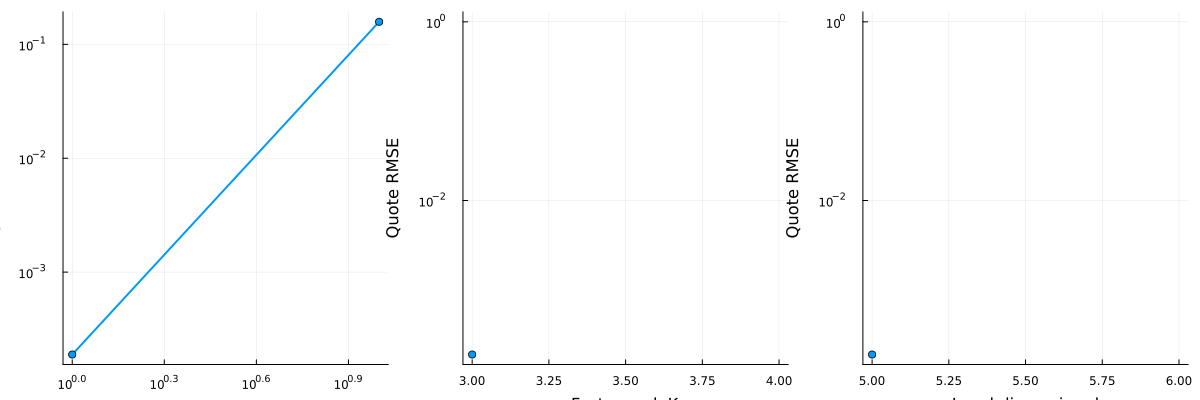

In [22]:
# Figure B: parameter stress at a fixed N and chi.
PLOT_STRESS = (N=50, chi=16, baseline_K=3, baseline_Q=2, baseline_rho=1.0)
STRESS_METRIC = :quote_rmse  # Change to :residual when desired.

function wb_median_curve(records, xfield, metric)
    xs = sort(unique(getproperty.(records, xfield)))
    ys = [median([getproperty(r, metric) for r in records if getproperty(r, xfield) == x]) for x in xs]
    return xs, ys
end

function wb_stress_figure(results, selector, metric)
    base = filter(r -> r.N == selector.N && r.chi == selector.chi, results)
    isempty(base) && error("No completed runs match PLOT_STRESS")
    ylabel = metric == :quote_rmse ? "Quote RMSE" : "Ritz residual"

    rho_rows = filter(r -> r.K == selector.baseline_K && r.Q == selector.baseline_Q, base)
    K_rows = filter(r -> r.rho == selector.baseline_rho && r.Q == selector.baseline_Q, base)
    Q_rows = filter(r -> r.K == selector.baseline_K && r.rho == selector.baseline_rho, base)

    rho_x, rho_y = wb_median_curve(rho_rows, :rho, metric)
    K_x, K_y = wb_median_curve(K_rows, :K, metric)
    Q_x, Q_y = wb_median_curve(Q_rows, :d, metric)

    p_rho = plot(rho_x, max.(rho_y, 1e-14); marker=:circle, linewidth=2,
        xscale=:log10, yscale=:log10, xlabel="Factor strength rho", ylabel, legend=false, grid=true)
    p_K = plot(K_x, max.(K_y, 1e-14); marker=:circle, linewidth=2,
        yscale=:log10, xlabel="Factor rank K", ylabel, legend=false, grid=true)
    p_d = plot(Q_x, max.(Q_y, 1e-14); marker=:circle, linewidth=2,
        yscale=:log10, xlabel="Local dimension d", ylabel, legend=false, grid=true)

    fig = plot(p_rho, p_K, p_d; layout=(1,3), size=(1200,400))
    metric_name = String(metric)
    savefig(fig, joinpath(WB_OUTPUT_ROOT, "stress_$(metric_name).pdf"))
    savefig(fig, joinpath(WB_OUTPUT_ROOT, "stress_$(metric_name).png"))
    return fig
end

isempty(WB_RESULTS) ? println("Run or load experiments first.") : wb_stress_figure(WB_RESULTS, PLOT_STRESS, STRESS_METRIC)

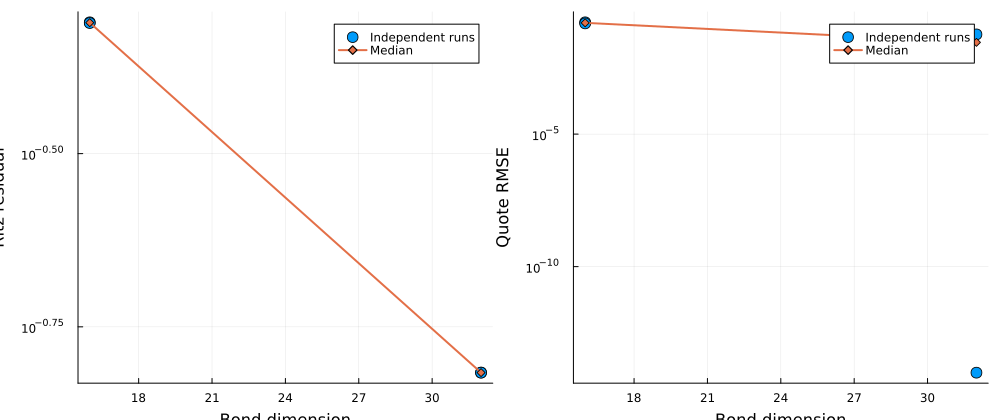

In [23]:
# Figure C: sensitivity to random DMRG initialization.
PLOT_MULTISEED = (N=50, K=3, Q=2, rho=10.0, instance_seed=1)

function wb_multiseed_figure(results, selector)
    selected = filter(r -> r.N == selector.N && r.K == selector.K && r.Q == selector.Q &&
        r.rho == selector.rho && r.instance_seed == selector.instance_seed, results)
    isempty(selected) && error("No completed runs match PLOT_MULTISEED")

    chis, median_residual = wb_median_by_chi(selected, :residual)
    _, median_quote = wb_median_by_chi(selected, :quote_rmse)

    p_residual = scatter(getproperty.(selected, :chi), getproperty.(selected, :residual);
        yscale=:log10, xlabel="Bond dimension", ylabel="Ritz residual",
        label="Independent runs", markersize=6, grid=true)
    plot!(p_residual, chis, median_residual; marker=:diamond, linewidth=2, label="Median")

    quote_values = max.(getproperty.(selected, :quote_rmse), 1e-14)
    p_quote = scatter(getproperty.(selected, :chi), quote_values;
        yscale=:log10, xlabel="Bond dimension", ylabel="Quote RMSE",
        label="Independent runs", markersize=6, grid=true)
    plot!(p_quote, chis, max.(median_quote, 1e-14);
        marker=:diamond, linewidth=2, label="Median")

    fig = plot(p_residual, p_quote; layout=(1,2), size=(1000,420))
    savefig(fig, joinpath(WB_OUTPUT_ROOT, "multiseed_convergence.pdf"))
    savefig(fig, joinpath(WB_OUTPUT_ROOT, "multiseed_convergence.png"))
    return fig
end

isempty(WB_RESULTS) ? println("Run or load experiments first.") : wb_multiseed_figure(WB_RESULTS, PLOT_MULTISEED)

## Suggested experiment expansions

The starter configuration contains only 16 runs. Increase one axis at a time:

1. **Check bond convergence:** set `chis = [16, 32, 64, 96, 128]` for one fixed model and 3 DMRG seeds.
2. **Measure model variability:** keep one moderate `chi` grid and use `instance_seeds = collect(1:10)`.
3. **Map factor coupling:** use `rhos = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0]` at fixed `N`, `K`, and `Q`.
4. **Map asset scaling:** use `Ns = [20, 50, 100, 200]` while keeping `K`, `rho`, and economic parameters fixed.
5. **Map factor rank and inventory width:** expand `Ks = [1, 2, 3, 5, 10]` and then `Qs = [2, 5, 10, 15]` in separate runs. Large `Q` is expensive because the local dimension is `2Q+1`.

Use a new `tag` for each study. Keep `overwrite = false`; adding new points to an existing configuration is safe because matching checkpoints are skipped. For long unattended runs, first execute one point at the largest planned `N`, `Q`, and `chi` to estimate its runtime and memory use.

The number of runs is
$$
|N|\,|K|\,|Q|\,|\rho|\,|\text{instance seeds}|\,|\chi|\,|\text{DMRG seeds}|.
$$
Avoid expanding every axis simultaneously.